In [6]:
%load_ext autoreload
%autoreload 2

In [121]:
import numpy as np
import pandana as pdna
import geopandas as gpd
import pandas as pd
import osmnx as ox
import math
import networkx as nx
import sys
import matplotlib.pyplot as plt
# adding functions 
sys.path.insert(0, 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Open-Walk-Index')
from walkability_functions import *

Choose a projected CRS to be used for all distance calculations.

In [8]:
folder = "C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Colouring data & results\\"
proj_crs = "EPSG:7856"

place = 'Sydney, Australia'
place_gdf = ox.geocode_to_gdf(place).to_crs(proj_crs)

#place_gdf = gpd.read_file(folder + 'Canberra Data\\Canberra Metro SA3s.gpkg', crs="EPSG:4326").to_crs(proj_crs)

<AxesSubplot:>

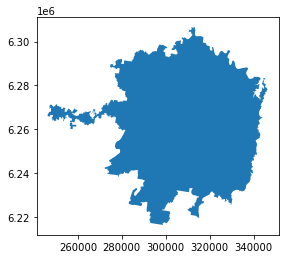

In [9]:
# check that we have the right area
place_gdf.geometry.plot()

## Import Data

Data sources:
1. OSM POIs
5. Employment data - find govt source

In [10]:
poi_dictionary = {
    'employment':{
        'category':['employment']
    },
    'shopping':{
        'shop':['bakery', 'clothes', 'supermarket', 'mall', 'greengrocer',
                'seafood', 'wine', 'butcher','convenience',
                'beverages', 'alcohol', 'bicycle_shop', 'department_store', 
                'doityourself', 'beauty_shop', 'outdoor_shop', 
                'stationery', 'bookshop', 'gift_shop', 'newsagent', 
                'car_dealership', 'furniture_shop', 'sports_shop',
                'garden_centre', 'computer_shop', 'shoe_shop', 'florist', 
                'video_shop', 'toy_shop', 'mobile_phone_shop', 'jeweller'],
        # possibly we could pick up all shop=True excluding a few. but not sure how
        # and many options to exclude
        'amenity':['marketplace'],
        'building':['kiosk', 'supermarket',],
    },
    'errands':{
        'amenity':['atm','bank','courthouse','post_box', 'post_office',
                   'clinic', 'dentist', 'doctors', 'hospital',
                   'pharmacy', 'veterinary', 'travel_agent',
                   'place_of_worship'],
        'shop':['optician', 'hairdresser', 'laundry',],
        'healthcare':['physiotherapist'],
        'office':['government'], #### further refine ?
    },
    'recreation':{
        'leisure':['dog_park', 'ice_rink', 'park', 'pitch', 'playground',
                   "fitness_centre","sports_centre", 'stadium', 'swimming_pool',
                   'swimming_area', 'track', 'water_park','golf_course',],
        'club':['social'],
        'amenity':['bar', 'biergarten', 'cafe', 'fast_food', 'food_court',
                   'ice_cream', 'pub', 'restaurant', 'nightclub',
                   'library', 'arts_centre', 'cinema', 'community_centre',
                   'social_centre', 'theatre',],
        'building':['stadium', 'castle', 'ruins',],
        'tourism':['aquarium', 'artwork', 'attraction', 'gallery',
                   'museum', 'picnic_site', 'theme_park', 'viewpoint',
                   'zoo'],
        'natural':['beach'],
    },
    'education':{
        'amenity':['college', 'kindergarten', 'music_school',
                   'school', 'university', 'childcare'],
    }
}

In [ ]:
osm_pois = poi_downloader(place_gdf, poi_dictionary, proj_crs, timeout=600)

In [12]:
employment_centrs = gpd.read_file((folder + 
                        "Sydney Data\\Data\\Centroids employment MBs.gpkg")).to_crs(proj_crs)

employment_centrs['category'] = 'employment'
employment_centrs['geometry'] = employment_centrs.geometry.centroid

Need to remove potential overlap between different data sources (and inside some data sources). For now I'm not worrying about this when using only OSM data. Then take this combined POI set and clip it to the study area: should be the same area as is covered by the network. This is important otherwise points outside the network may be erroneously linked to the network.

In [13]:
pois = pd.concat([osm_pois, employment_centrs])

pois = gpd.clip(pois, place_gdf.to_crs(proj_crs))

### Categorise and weight POIs

Choose walk index weightings, and output the sums of each category and the total to check. The walk index will be out of 100 regardless of this sum, but it is important to note that eg. shopping is only '10% of the walk index' if shopping is 10 out of 100.

In [14]:
poi_parameters = pd.read_csv((folder + 
                              "Shared Aus Data\\poi_parameters_5.csv"),
                            index_col=0)

In [15]:
poi_weights = poi_parameters['weight'].copy()

poi_lambdas = poi_parameters['diminishing_returns_constant'].copy()

poi_variables = poi_parameters['variable'].copy()

poi_nums = poi_parameters['num_pois'].copy()

poi_gammas = poi_parameters['distance_constant'].copy()

In [16]:
total = sum(poi_weights)
print("total: ", total)

total:  100.00000000000001


In [17]:
# change this to match the column containting job counts in your employment dataframe
poi_variables.loc['employment'] = 'Jobs_count'
# change this to make employment score more accurate (higher number) or to reduce index calculation time (low number)
poi_nums.loc['employment'] = 1200

In [18]:
restaurants = pois[pois['amenity']=='restaurant']

In [133]:
parks = pois[pois['leisure']=='park']

In [134]:
parks

,tourism,geometry,name,source,natural,wikidata,direction,amenity,operator,brand,...,DZNs w MB employment areas_Education,DZNs w MB employment areas_Hospital/Medical,DZNs w MB employment areas_Industrial,DZNs w MB employment areas_Other,DZNs w MB employment areas_Primary Production,DZNs w MB employment areas_Sum Empl. MB Areas,DZNs w MB employment areas_DZN_jobs,DZNs w MB employment areas_jobs_area,Jobs_count,category
"(way, 33996592)",NaN,POINT (287519.662 6225716.857),Bowman Reserve,survey,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 39162330)",NaN,POINT (286731.287 6225793.145),Hayter Reserve,survey,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 562380765)",NaN,POINT (289665.635 6227037.668),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 39345395)",NaN,POINT (286575.174 6225688.631),Camden Rugby Park,Yahoo,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 34618940)",NaN,POINT (287101.103 6225814.398),Crookston Reserve,survey,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(way, 394514551)",NaN,POINT (303722.917 6293192.570),Sackville North Memorial Park,NSW LPI Base Map,NaN,Q21937795,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 576148369)",NaN,POINT (292305.667 6287475.677),Woodbury Park,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 1062102223)",NaN,POINT (292626.372 6288037.300),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 642003673)",NaN,POINT (295580.662 6290313.012),Stanley Park,LPI Base Map Apr 2019,NaN,Q21936166,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Import network

Pandana expects edges to have a two item index based on the same IDs as the node index. (with thanks to https://github.com/shriv/accessibility-series/blob/master/Accounting%20for%20hills%20in%20accessibility%20analyses.ipynb)

In [19]:
#G = ox.graph_from_place(place, network_type='walk')
G = ox.graph.graph_from_polygon(place_gdf.to_crs('EPSG:4326').geometry[0], network_type='walk')

In [20]:
# Get nodes and edges as geodataframes (gdfs) from OSMNX network
graph_df = ox.graph_to_gdfs(G)
nodes_gdfs = graph_df[0]
edges_gdfs = graph_df[1]

In [21]:
edges_gdfs = edges_gdfs.to_crs(proj_crs)
nodes_gdfs = nodes_gdfs.to_crs(proj_crs)

## Pandana network creation.

In [22]:
# with new OSMnx graph from polygon seems to be different
edges_gdfs = edges_gdfs.reset_index()
# Setting indices of Edges gdfs to match expected dataframe for Pandana
edges_gdfs['from_idx'] = edges_gdfs['u']
edges_gdfs['to_idx'] = edges_gdfs['v']
edges_gdfs= edges_gdfs.set_index(['from_idx', 'to_idx'])
edges_gdfs.index.names= ['','']

# Setting indices of Nodes gdfs to match expected dataframe for Pandana
nodes_gdfs.index.name = 'id'
# Create a pandana network with data extracted from an OSMNX graph
distance_network = pdna.Network(nodes_gdfs.geometry.x, nodes_gdfs.geometry.y,
                                   edges_gdfs['u'], edges_gdfs['v'], 
                                   edges_gdfs[['length']])

In [24]:
nodes_gdfs.set_index('id_node', inplace= True)

KeyError: "None of ['id_node'] are in the columns"

### Pandana network querying. 

In [26]:
# set origin point. I would like the corner of Elizabeth and McEvoy st, for no particular reason
#151.2003, -33.901
nodes_gdfs[(nodes_gdfs.y > -33.923) & (nodes_gdfs.y < -33.92) & (nodes_gdfs.x < 151.241) & (nodes_gdfs.x > 151.24)]
house = 18544768

Find eg 10 closest in some category

In [27]:
restaurants = restaurants.reset_index()

In [28]:
num_pois = 30
distance_network.set_pois(category = 'restaurants',
                 maxdist = 1000,
                 maxitems = num_pois,
                 x_col = restaurants.geometry.x, 
                 y_col = restaurants.geometry.y)
result = distance_network.nearest_pois(distance = 1000,
                               category = 'restaurants',
                               num_pois = num_pois,
                               include_poi_ids = True)

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\pandana\network.py:660: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  elif isinstance(maxitems, type(pd.Series())):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\pandana\network.py:668: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  elif isinstance(maxdist, type(pd.Series())):


In [135]:
num_pois = 30
distance_network.set_pois(category = 'parks',
                 maxdist = 1000,
                 maxitems = num_pois,
                 x_col = parks.geometry.x, 
                 y_col = parks.geometry.y)
parks_result = distance_network.nearest_pois(distance = 1000,
                               category = 'parks',
                               num_pois = num_pois,
                               include_poi_ids = True)

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\pandana\network.py:660: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  elif isinstance(maxitems, type(pd.Series())):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\pandana\network.py:668: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  elif isinstance(maxdist, type(pd.Series())):


Then get shortest path

In [30]:
dest_list = [int(result[result.index == house].iloc[:,num_pois + n]) for n in range(num_pois)]
res = restaurants.loc[dest_list]
dest_nodes = distance_network.get_node_ids(res.geometry.x, res.geometry.y).values

In [30]:
park_dest_list = [int(result[result.index == house].iloc[:,num_pois + n]) for n in range(num_pois)]
parks_result = parks.loc[park_dest_list]
dest_nodes = distance_network.get_node_ids(res.geometry.x, res.geometry.y).values

In [31]:
#origs = [o for o in restaurant_nodes for d in restaurant_nodes]
#dests = [d for o in restaurant_nodes for d in restaurant_nodes]

origins = np.asarray([house]*num_pois, dtype=np.int64)
#%%time
routes = distance_network.shortest_paths(origins, dest_nodes)

In [32]:
lengths = distance_network.shortest_path_lengths(origins, dest_nodes)

In [33]:
routelist = [list(route) for route in routes]

Somehow map shortest paths on top of the whole network. OSMNX has some functionality for this

In [34]:
cbd = [-33.88, -33.94, 151.24, 151.18]
alexandria = [-33.89, -33.91, 151.21, 151.19]
east = [-33.89, -33.93, 151.26, 151.22]

In [246]:
cbd_graph = ox.truncate.truncate_graph_bbox(G, cbd[0], cbd[1], cbd[2], cbd[3], 
                                               truncate_by_edge=True, retain_all=True, 
                                               quadrat_width=0.05, min_num=3)

In [242]:
alexandria_graph = ox.truncate.truncate_graph_bbox(G, alexandria[0], alexandria[1], alexandria[2], alexandria[3], 
                                               truncate_by_edge=True, retain_all=True, 
                                               quadrat_width=0.05, min_num=3)

In [35]:
east_graph = ox.truncate.truncate_graph_bbox(G, east[0], east[1], east[2], east[3], 
                                               truncate_by_edge=True, retain_all=True, 
                                               quadrat_width=0.05, min_num=3)

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


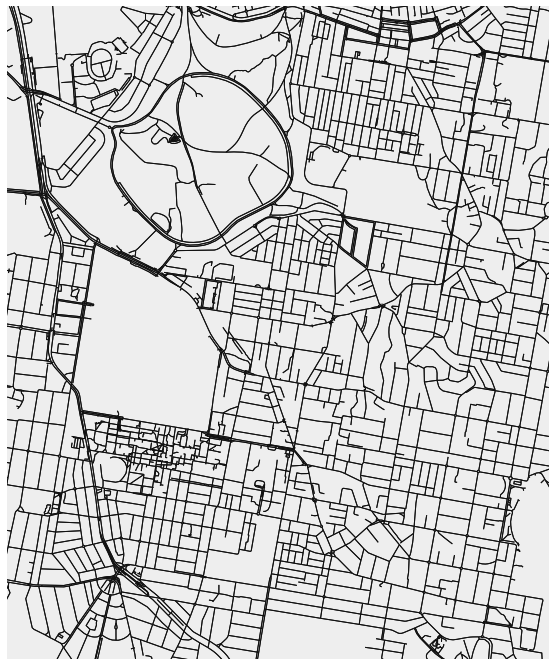

(<Figure size 864x864 with 1 Axes>, <AxesSubplot:>)

In [36]:
ox.plot.plot_graph(east_graph, figsize=(12, 12), 
                   bgcolor='#eeeeee', 
                   node_color='black', node_size=0, node_alpha=None, node_edgecolor='none', node_zorder=1, 
                   edge_color='#111111', edge_linewidth=1, edge_alpha=None, 
                   show=True, close=False, save=False, filepath=None, dpi=300, bbox=east)

In [57]:
def JR_plot_graph_route(G,
    route,
    route_color="r",
    route_linewidth=4,
    route_alpha=0.5,
    orig_dest_size=100,
    ax=None,
    **pg_kwargs,):
    if ax is None:
        # plot the graph but not the route, and override any user show/close
        # args for now: we'll do that later
        override = {"show", "save", "close"}
        kwargs = {k: v for k, v in pg_kwargs.items() if k not in override}
        fig, ax = ox.plot_graph(G, show=False, save=False, close=False, **kwargs)
    else:
        fig = ax.figure

    # scatterplot origin and destination points (first/last nodes in route)
    x = (G.nodes[route[0]]["x"], G.nodes[route[-1]]["x"])
    y = (G.nodes[route[0]]["y"], G.nodes[route[-1]]["y"])
    ax.scatter(x, y, s=orig_dest_size, c=route_color, alpha=route_alpha, edgecolor="none")

    # assemble the route edge geometries' x and y coords then plot the line
    x = []
    y = []
    for u, v in zip(route[:-1], route[1:]):
        # if there are parallel edges, select the shortest in length
        data = min(G.get_edge_data(u, v).values(), key=lambda d: d["length"])
        if "geometry" in data:
            # if geometry attribute exists, add all its coords to list
            xs, ys = data["geometry"].xy
            x.extend(xs)
            y.extend(ys)
        else:
            # otherwise, the edge is a straight line from node to node
            x.extend((G.nodes[u]["x"], G.nodes[v]["x"]))
            y.extend((G.nodes[u]["y"], G.nodes[v]["y"]))
    ax.plot(x, y, c=route_color, lw=route_linewidth, alpha=route_alpha)
    
    return fig, ax

In [108]:
def JR_plot_graph_routes(G, routes, route_colors="r", route_linewidths=4, orig_dest_sizes=100, **pgr_kwargs):
    """
    Plot several routes along a graph.
    Parameters
    ----------
    G : networkx.MultiDiGraph
        input graph
    routes : list
        routes as a list of lists of node IDs
    route_colors : string or list
        if string, 1 color for all routes. if list, the colors for each route.
    route_linewidths : int or list
        if int, 1 linewidth for all routes. if list, the linewidth for each route.
    pgr_kwargs
        keyword arguments to pass to plot_graph_route
    Returns
    -------
    fig, ax : tuple
        matplotlib figure, axis
    """
    # check for valid arguments
    if not all(isinstance(r, list) for r in routes):  # pragma: no cover
        raise ValueError("routes must be a list of route lists")
    if len(routes) < 2:  # pragma: no cover
        raise ValueError("You must pass more than 1 route")
    if isinstance(route_colors, str):
        route_colors = [route_colors] * len(routes)
    if len(routes) != len(route_colors):  # pragma: no cover
        raise ValueError("route_colors list must have same length as routes")
    if isinstance(route_linewidths, int):
        route_linewidths = [route_linewidths] * len(routes)
    if isinstance(orig_dest_sizes, int):
        orig_dest_sizes = [orig_dest_sizes] * len(routes)    
    if len(routes) != len(route_linewidths):  # pragma: no cover
        raise ValueError("route_linewidths list must have same length as routes")

    # plot the graph and the first route
    override = {"route", "route_color", "route_linewidth", "orig_dest_sizes", "show", "save", "close"}
    kwargs = {k: v for k, v in pgr_kwargs.items() if k not in override}
    fig, ax = JR_plot_graph_route(
        G,
        route=routes[0],
        route_color=route_colors[0],
        route_linewidth=route_linewidths[0],
        orig_dest_size=orig_dest_sizes[0],
        show=False,
        save=False,
        close=False,
        **kwargs,
    )

    # plot the subsequent routes on top of existing ax
    override.update({"ax"})
    kwargs = {k: v for k, v in pgr_kwargs.items() if k not in override}
    r_rc_rlw_od = zip(routes[1:], route_colors[1:], route_linewidths[1:], orig_dest_sizes[1:])
    for route, route_color, route_linewidth, route_o_d_size in r_rc_rlw_od:
        fig, ax = JR_plot_graph_route(
            G,
            route=route,
            route_color=route_color,
            route_linewidth=route_linewidth,
            orig_dest_size=route_o_d_size,
            show=False,
            save=False,
            close=False,
            ax=ax,
            **kwargs,
        )

    # save and show the figure as specified, passing relevant kwargs
    # removed this and it works better for me
    return fig, ax

In [91]:
selectedroutes = routelist[11:20] + routelist[28:29]
selectedlengths = lengths[11:20] + lengths[28:29]

In [119]:
# create route colors
rc = ['r', 'y', 'c']
selectedwidths = [6 - 3.5*x/max(lengths) for x in selectedlengths]
selectedsizes = [200 - 150*x/max(lengths) for x in selectedlengths]
widths = [3 - 2.5*x/max(lengths) for x in lengths]
# width by order too? routes are already sorted by length
orderwidths = [6 - 3.5*(i/30)*x/max(lengths) for i, x in enumerate(lengths)]

In [115]:
[x for x in enumerate(lengths)]

[(0, 253.902),
 (1, 355.971),
 (2, 383.667),
 (3, 383.667),
 (4, 392.294),
 (5, 392.294),
 (6, 392.294),
 (7, 392.294),
 (8, 435.776),
 (9, 435.776),
 (10, 435.776),
 (11, 452.415),
 (12, 504.519),
 (13, 504.519),
 (14, 504.519),
 (15, 532.16),
 (16, 580.64),
 (17, 580.64),
 (18, 607.559),
 (19, 698.698),
 (20, 703.851),
 (21, 703.851),
 (22, 798.036),
 (23, 841.719),
 (24, 897.624),
 (25, 927.793),
 (26, 936.517),
 (27, 936.517),
 (28, 937.414),
 (29, 937.414)]

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


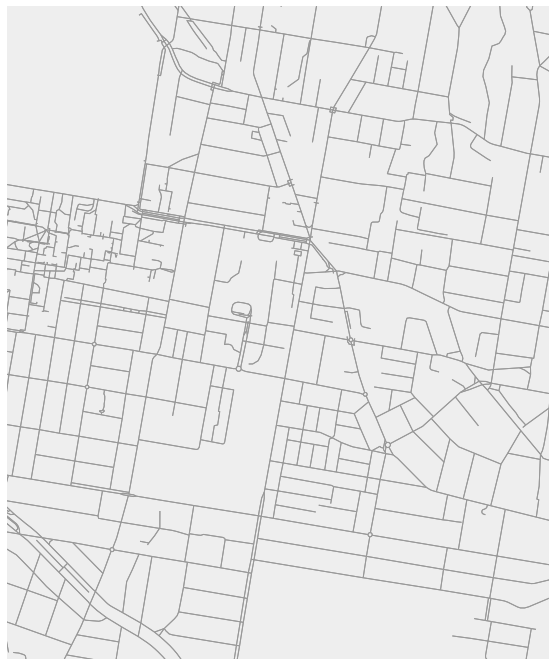

In [92]:
#fig, ax = plt.subplots()
graphplot, ax = ox.plot_graph(east_graph, figsize=(12, 12), bgcolor='#eeeeee',
                              bbox=[-33.91, -33.93, 151.25, 151.23],
                   node_color='black', node_size=0, node_alpha=None, node_edgecolor='none', node_zorder=1, 
                             #edge_color='#111111', edge_linewidth=1
                             )

In [104]:
selectedroutes

[[18544768,
  1822130979,
  1822130493,
  9681846347,
  1839046587,
  42700394,
  1822130929,
  1822131093,
  1822130276],
 [18544768,
  1835527904,
  1839625074,
  1835527889,
  1839130275,
  1822130307,
  6085374802,
  6085453238],
 [18544768,
  1835527904,
  1839625074,
  1835527889,
  1839130275,
  1822130307,
  6085374802,
  6085453238],
 [18544768,
  1835527904,
  1839625074,
  1835527889,
  1839130275,
  1822130307,
  6085374802,
  6085453238],
 [18544768,
  1835527904,
  1839625074,
  1835527889,
  1839625076,
  1837898362,
  8911116928,
  5584362880,
  1835528456,
  5584362875,
  2744090711,
  6517484668],
 [18544768,
  1835527904,
  1839625074,
  1835527889,
  1839625076,
  1837898362,
  8911116928,
  5584362880,
  1835528456,
  5584362875,
  2744090711,
  6517484668,
  6009787980],
 [18544768,
  1835527904,
  1839625074,
  1835527889,
  1839625076,
  1837898362,
  8911116928,
  5584362880,
  1835528456,
  5584362875,
  2744090711,
  6517484668,
  6009787980],
 [18544768,
  1

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


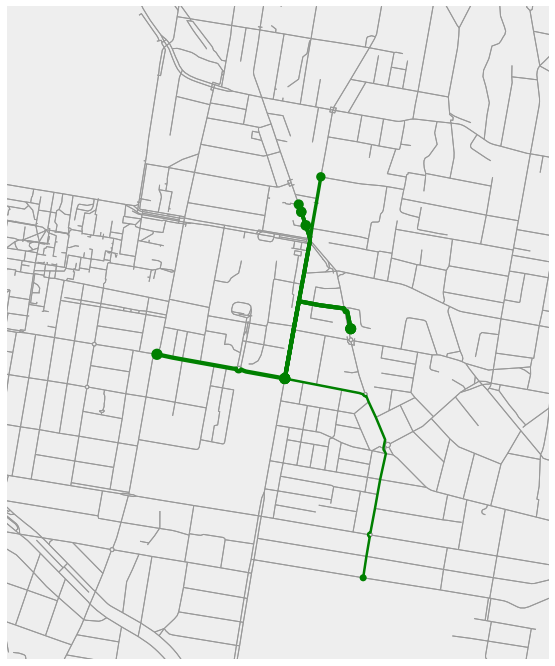

In [110]:
fig, ax = JR_plot_graph_routes(east_graph, 
                               selectedroutes, route_colors='g', route_linewidths=selectedwidths, route_alpha=1, 
                             orig_dest_sizes=selectedsizes,
                               figsize=(12, 12), bgcolor='#eeeeee',
                              bbox=[-33.91, -33.93, 151.25, 151.23],
                   node_color='black', node_size=0, node_alpha=None, node_edgecolor='none', node_zorder=1, 
                             #edge_color='#111111', edge_linewidth=1
                    show=True)
# after all that I can't remember why I wanted it
#JR_plot_graph_route(east_graph, selectedroutes[1], route_color='r', #route_linewidth=selectedwidths[1], #route_alpha=alpha, 
#                        route_linewidth=4,
#    route_alpha=0.5, orig_dest_size=500,
#                    ax=ax,show=True
#                   )

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


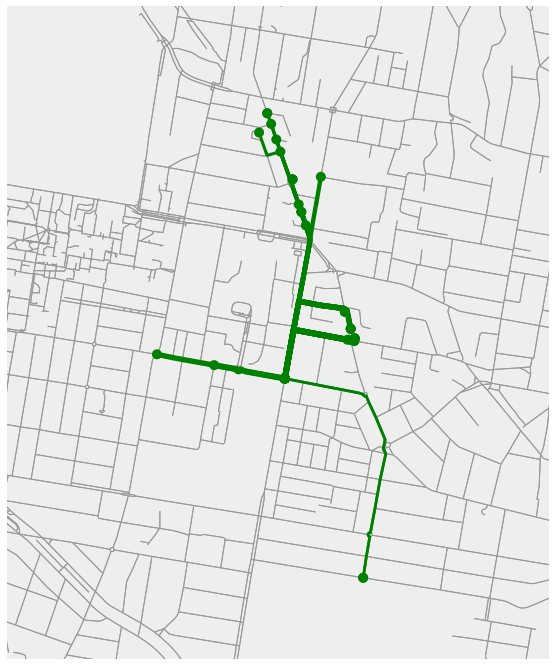

In [120]:
fig, ax = JR_plot_graph_routes(east_graph, 
                               routelist, route_colors='g', route_linewidths=orderwidths, route_alpha=1, 
                         #orig_dest_size=10, ax=ax,
                               figsize=(12, 12), bgcolor='#eeeeee',
                              bbox=[-33.91, -33.93, 151.25, 151.23],
                   node_color='black', node_size=0, node_alpha=None, node_edgecolor='none', node_zorder=1, 
                             #edge_color='#111111', edge_linewidth=1
                    show=True)
# after all that I can't remember why I wanted it
#JR_plot_graph_route(east_graph, selectedroutes[1], route_color='r', #route_linewidth=selectedwidths[1], #route_alpha=alpha, 
#                        route_linewidth=4,
#    route_alpha=0.5, orig_dest_size=500,
#                    ax=ax,show=True
#                   )

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


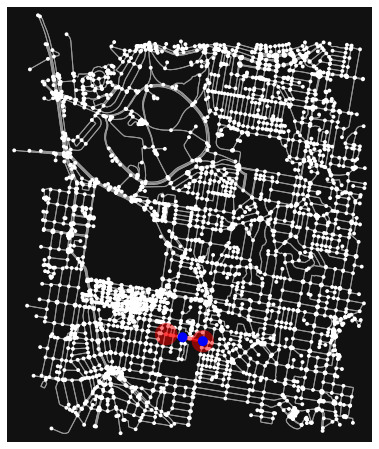

In [58]:
fig, ax = JR_plot_graph_route(east_graph, selectedroutes[1], route_color='r', #route_linewidth=selectedwidths[1], #route_alpha=alpha, 
                        route_linewidth=4,
    route_alpha=0.5, orig_dest_size=500,
                    #ax=ax,show=True
                   )

x = (G.nodes[selectedroutes[0][0]]["x"], G.nodes[selectedroutes[0][-1]]["x"])
y = (G.nodes[selectedroutes[0][0]]["y"], G.nodes[selectedroutes[0][-1]]["y"])
ax.scatter(x, y, s=100, c='b', edgecolor="none",zorder=5)

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


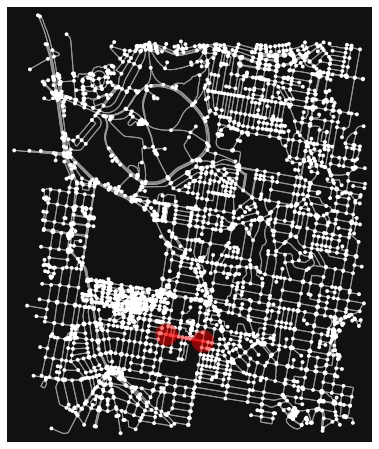

In [431]:
graphplot, ax = ox.plot_graph_route(east_graph, selectedroutes[1], route_color='r', #route_linewidth=selectedwidths[1], #route_alpha=alpha, 
                         orig_dest_size=500,
                    show=True)

In [ ]:
ox.plot_graph_route(east_graph, selectedroutes[1], route_color='r', route_linewidth=selectedwidths[1], #route_alpha=alpha, 
                         orig_dest_size=500,
                    )

In [ ]:
widths

In [5]:
# create route colors
rc0 = ['r'] * (len(routelist[0]) - 1)
rc1 = ['b'] * len(routelist[1])
rc2 = ['y'] * len(routelist[2])
rc = rc0 + rc1 + rc2
nc = ['r', 'r', 'b', 'b', 'y', 'y']
                               
ox.plot_graph_route(east_graph, routelist[2], route_color='b', route_linewidth=4, route_alpha=0.5, 
                         orig_dest_size=100,
                     figsize=(12, 12), bgcolor='#eeeeee',
                   node_color='black', node_size=0, node_alpha=None, node_edgecolor='none', node_zorder=1, 
                   edge_color='#111111', edge_linewidth=1, edge_alpha=None)

NameError: name 'routelist' is not defined

In [ ]:
osmnx.plot.plot_graph_routes(G, routes, route_colors='r', route_linewidths=4, **pgr_kwargs)

#### Old stuff

In [ ]:
maximum_dist=2400

In [ ]:
results_walk = there_index(distance_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=maximum_dist)

In [ ]:
max(results_walk['THERE_Index']), np.mean(results_walk['THERE_Index'])

The current approach is to find up to x closest nodes for each category within the maximum distance. Then look up the attractiveness at each one (just count for most), apply a distance decay function to each distance, apply diminishing returns to the resulting total opportunity, and sum.

An alternative approach which would be more convenient would be to use the Pandana 'aggregate' function which aggregates from all nodes within the maximum distance including applying a decay function. However, there is limited ability to change the distance decay rate within the aggregation function. It can either be flat (no decay), linear (going to 0 at the max distance), or exponential where beta is set as 1/max distance. For walking I would like a beta of 0.001, but this requires the radius to be 1000m. If the radius is 2400m, beta is only 0.0004. This can be changed in the future if the Pandana function is updated to take a decay parameter.

## Export results

Reduce the number of decimal places before export, distances do not need to be below 1m.

In [ ]:
def result_rounding(results):
    # reduces results size for export
    # score columns such as THERE_Index, employment_subtotal etc -> 3 decimal places
    # distance columns such as employment1 -> 0 decimal places (nearest metre)
    # avoid doing anything to connect_id, x or y
    rounding_dict = {**{k:3 for k in results.columns if "Index" in k or "." in k
                        and 'connect_id' not in k},
                     **{k:0 for k in results.columns if "Index" not in k and "." not in k
                        and k != 'x'
                        and k != 'y'}}
    return results.round(rounding_dict)

In [ ]:
small_w_results = gpd.GeoDataFrame(result_rounding(results_walk), geometry = gpd.GeoSeries.from_xy(results_walk.x, results_walk.y, crs=proj_crs))

 ### Population weighted results

Import smallest statistical unit for which population data is available (meshblocks in Australia). Join this to the results (by population weighted centroid location if available, otherwise geometric centroid location). Then results can be graphed or visualised by population, giving a more accurate picture of the population access by walking.

In [ ]:
meshblocks = gpd.read_file(folder + "Sydney Data\\Data\\2016_NSW_MBs\\MB_2016_NSW.shp").to_crs(proj_crs)
meshblocks['MB_CODE16'] = meshblocks['MB_CODE16'].astype('int64')
meshblocks.geometry = meshblocks.centroid

In [3]:
population = pd.read_csv(folder + "Sydney Data\\Data\\2016_NSW_MBs\\2016 census mesh block counts.csv")
population = population.set_index('MB_CODE_2016')

NameError: name 'pd' is not defined

In [ ]:
meshblocks = meshblocks.join(population, on='MB_CODE16', how='left')

In [ ]:
meshblocks_w = meshblocks.sjoin_nearest(small_w_results, how='left', rsuffix = 'walk')
meshblocks_w = meshblocks_w.clip(place_gdf)

Population weighted average THERE index:

In [ ]:
sum(meshblocks_w['Person']*meshblocks_w['THERE_Index'])/sum(meshblocks_w['Person'])

In [ ]:
meshblocks_w = gpd.read_file((folder + "Sydney Data\\Sydney MB results walk 190722.gpkg"))

In [ ]:
cm = plt.cm.Greens
bins=[10,20,30,40,50,60,70,80,90,100]
fig, ax1 = plt.subplots(nrows=1, ncols=1, sharey=True, figsize=(12, 4))
fig.set_figwidth(4)
ax1.set_xlabel('WalkTHERE')
ax1.set_ylabel('Residents')
fig.suptitle('Sydney: distribution of results by residential population')

n, bins, patches = plt.hist(meshblocks_w['THERE_Index'], weights = meshblocks_w['Person'], label='WalkTHERE',bins=bins)
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/10 + 0.2)) # notice the i/25
    
plt.show()

### Visualise results

In [ ]:
small_w_results.plot(column="THERE_Index", legend=True,
                     cmap='Greens',figsize=(20,20),markersize=1)

In [ ]:
small_w_results.plot(column="employment_31.9", cmap='Greens',figsize=(20,20),markersize=1)

In [ ]:
meshblocks_w.to_file((folder + "Sydney Data\\Sydney MB results walk 190722.gpkg"))